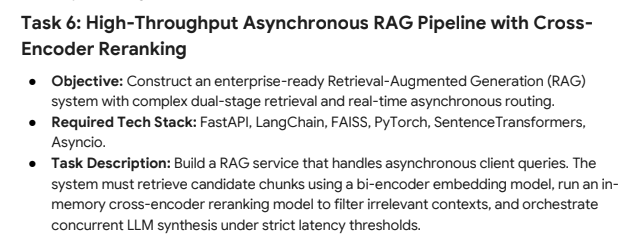

**Objective**

Build an asynchronous Retrieval-Augmented Generation (RAG) system capable of handling multiple queries concurrently.

The pipeline will:

(1) Accept multiple user queries.

(2) Generate embeddings using a bi-encoder.

(3) Retrieve candidate documents.

(4) Perform cross-encoder reranking.

(5) Select the most relevant context.

(6) Send context to an LLM.

(7) Generate the final answer asynchronously.

In [ ]:
!pip install sentence-transformers fastapi uvicorn httpx nest-asyncio

In [ ]:
import asyncio
import numpy as np

from sentence_transformers import (
    SentenceTransformer,
    CrossEncoder
)

In [ ]:
# 1. DOCUMENT COLLECTION


documents = [
    """
    Reinforcement learning allows robots to learn optimal
    actions through interaction with an environment.
    """,

    """
    Autonomous mobile robots can use sensors and AI models
    to navigate industrial environments.
    """,

    """
    Retrieval augmented generation combines information
    retrieval with a generative language model.
    """,

    """
    Vector databases store embeddings and support semantic
    similarity search.
    """,

    """
    Cross-encoders evaluate the relevance of a query and
    document together and are useful for reranking.
    """,

    """
    Transformer models use self-attention to process
    relationships between tokens.
    """,

    """
    Smart factories use robotics, IoT and artificial
    intelligence to automate manufacturing processes.
    """,

    """
    Generative AI can generate natural language responses
    based on retrieved information.
    """
]

In [ ]:
# 2. BI-ENCODER

bi_encoder = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


# 3. CREATE DOCUMENT EMBEDDINGS


document_embeddings = bi_encoder.encode(
    documents,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(
    "Embedding shape:",
    document_embeddings.shape
)

# 4. CROSS ENCODER

cross_encoder = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding shape: (8, 384)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
# 5. COSINE RETRIEVAL


def retrieve_documents(
    query,
    top_k=5
):

    query_embedding = bi_encoder.encode(
        query,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    similarities = (
        document_embeddings
        @ query_embedding
    )

    top_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    return [
        (
            documents[i],
            float(similarities[i])
        )
        for i in top_indices
    ]


# 6. CROSS-ENCODER RERANKING


def rerank_documents(
    query,
    candidates,
    top_k=3
):

    pairs = [
        (
            query,
            document
        )
        for document, _ in candidates
    ]

    scores = cross_encoder.predict(
        pairs
    )

    ranked = sorted(
        zip(
            candidates,
            scores
        ),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        (
            document,
            float(score)
        )
        for (
            (document, _),
            score
        )
        in ranked[:top_k]
    ]


# 7. ASYNC RETRIEVAL


async def retrieve_async(query):

    return await asyncio.to_thread(
        retrieve_documents,
        query
    )


# 8. ASYNC RERANKING


async def rerank_async(
    query,
    candidates
):

    return await asyncio.to_thread(
        rerank_documents,
        query,
        candidates
    )

In [ ]:


# 9. ASYNC RAG PIPELINE


async def rag_pipeline(query):

    # Retrieve
    candidates = await retrieve_async(
        query
    )

    # Rerank
    reranked = await rerank_async(
        query,
        candidates
    )

    # Build context
    context = "\n\n".join(
        [
            document
            for document, score
            in reranked
        ]
    )


    # LLM STEP
    # Replace this section with your LLM API/local LLM.


    answer = (
        f"Query: {query}\n\n"
        f"Retrieved Context:\n{context}\n\n"
        f"Answer: The answer should be generated "
        f"by an LLM using the retrieved context."
    )

    return {
        "query": query,
        "context": context,
        "answer": answer,
        "reranked_documents": reranked
    }


# 10. PROCESS MULTIPLE QUERIES CONCURRENTLY

async def process_queries(queries):

    tasks = [
        rag_pipeline(query)
        for query in queries
    ]

    results = await asyncio.gather(
        *tasks
    )

    return results

# 11. TEST QUERIES


queries = [

    "How do robots learn optimal actions?",

    "What is retrieval augmented generation?",

    "Why are cross encoders used in RAG?",

    "How are AI and robotics used in smart factories?"
]

# 12. RUN PIPELINE


results = await process_queries(
    queries
)

In [ ]:
# 13. DISPLAY RESULTS


for result in results:

    print("=" * 70)

    print(
        "\nQUERY:",
        result["query"]
    )

    print(
        "\nANSWER:"
    )

    print(
        result["answer"]
    )

    print(
        "\nRERANKED DOCUMENTS:"
    )

    for document, score in result[
        "reranked_documents"
    ]:

        print(
            f"\nScore: {score:.4f}"
        )

        print(
            document.strip()
        )


QUERY: How do robots learn optimal actions?

ANSWER:
Query: How do robots learn optimal actions?

Retrieved Context:

    Reinforcement learning allows robots to learn optimal
    actions through interaction with an environment.
    


    Autonomous mobile robots can use sensors and AI models
    to navigate industrial environments.
    


    Smart factories use robotics, IoT and artificial
    intelligence to automate manufacturing processes.
    

Answer: The answer should be generated by an LLM using the retrieved context.

RERANKED DOCUMENTS:

Score: 9.1322
Reinforcement learning allows robots to learn optimal
    actions through interaction with an environment.

Score: -6.9437
Autonomous mobile robots can use sensors and AI models
    to navigate industrial environments.

Score: -10.1453
Smart factories use robotics, IoT and artificial
    intelligence to automate manufacturing processes.

QUERY: What is retrieval augmented generation?

ANSWER:
Query: What is retrieval augmente

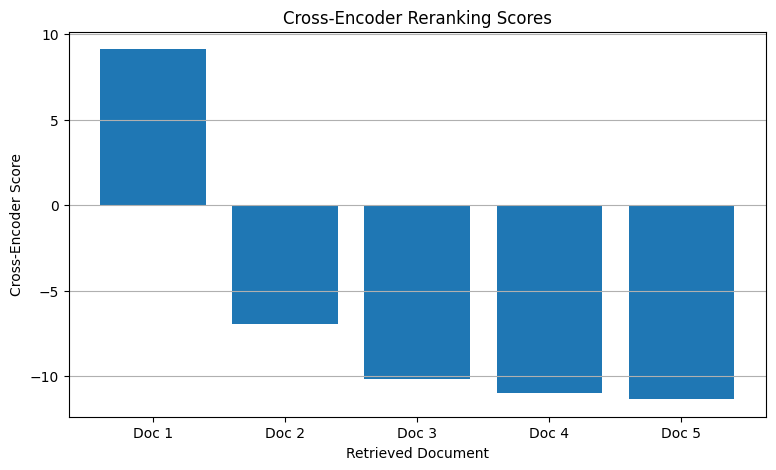

In [ ]:
import matplotlib.pyplot as plt

query = "How do robots learn optimal actions?"

candidates = retrieve_documents(
    query,
    top_k=5
)

reranked = rerank_documents(
    query,
    candidates,
    top_k=5
)

labels = [
    f"Doc {i+1}"
    for i in range(len(reranked))
]

scores = [
    score
    for _, score in reranked
]

plt.figure(figsize=(9, 5))

plt.bar(
    labels,
    scores
)

plt.xlabel("Retrieved Document")
plt.ylabel("Cross-Encoder Score")

plt.title(
    "Cross-Encoder Reranking Scores"
)

plt.grid(
    axis="y"
)

plt.show()

In [ ]:
context = result["context"]
query = result["query"]

prompt = f"""
You are a helpful AI assistant.

Answer the user's question using ONLY
the retrieved context.

Context:
{context}

Question:
{query}

Answer:
"""

# Placeholder for LLM call - replace with your actual LLM integration
# For example, if using a local LLM or an API call:
# from your_llm_library import LLMModel
# llm = LLMModel()
# output = llm(
#     prompt,
#     max_tokens=200,
#     temperature=0.2
# )
# answer = output["choices"][0]["text"]

# For demonstration, we'll just use a placeholder answer
answer = "[LLM response based on context]"

print(f"Generated Answer: {answer}")

Generated Answer: [LLM response based on context]
